## MODEL BUILDING LIFE CYCLE
1. Feature Encoding
2. Train-Test Split
3. Handle Class Imbalance by SMOTE
4. Feature Scaling
5. Model Training
6. Hyperparameter Tunning
7. Model Evaluation
8. Best Model Selection
9. SHAP Analysis
10. Model Saving (Pickle)

In [1]:
# Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# For Modelling
import pickle
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, precision_score, recall_score, roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv('data\preprocessed_data().csv')
data.head()

,Gender,Age_Range,Admission_Year,Faculty,Level_of_Study,Parental_Level_of_Education,Financial_Support_Source,CGPA_Range,Hours_of_Study_per_Week,Class_Attendance,Accommodation_Type,Working_while_studying,Internet_Access,Participation_in_Social_Activities,Scholarship_Status,Academic_support,Health_Challenges,School_Activities_Stress,Dropout_Risk
0,1,1,2023/2024,Food & Consumer Sciences (FFCS),2,1,Parents/Guardians,4,2,1,1,0,1,0,0,1,0,2,0
1,0,1,2021/2022,Computing and Informatics (FCI),4,0,Parents/Guardians,4,3,0,1,0,1,0,0,0,1,1,0
2,0,1,2021/2022,Computing and Informatics (FCI),4,3,Parents/Guardians,4,0,1,1,0,2,0,0,1,1,2,0
3,0,1,2021/2022,Computing and Informatics (FCI),4,3,Parents/Guardians,5,1,1,1,0,1,0,0,0,0,0,0
4,0,1,2021/2022,Computing and Informatics (FCI),4,2,Parents/Guardians,5,0,0,1,0,1,0,0,0,0,1,0


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 643 entries, 0 to 642
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Gender                              643 non-null    int64
 1   Age_Range                           643 non-null    int64
 2   Admission_Year                      643 non-null    str  
 3   Faculty                             643 non-null    str  
 4   Level_of_Study                      643 non-null    int64
 5   Parental_Level_of_Education         643 non-null    int64
 6   Financial_Support_Source            643 non-null    str  
 7   CGPA_Range                          643 non-null    int64
 8   Hours_of_Study_per_Week             643 non-null    int64
 9   Class_Attendance                    643 non-null    int64
 10  Accommodation_Type                  643 non-null    int64
 11  Working_while_studying              643 non-null    int64
 12  Internet_Access    

In [4]:
data.shape

(643, 19)

In [5]:
data.describe()

,Gender,Age_Range,Level_of_Study,Parental_Level_of_Education,CGPA_Range,Hours_of_Study_per_Week,Class_Attendance,Accommodation_Type,Working_while_studying,Internet_Access,Participation_in_Social_Activities,Scholarship_Status,Academic_support,Health_Challenges,School_Activities_Stress,Dropout_Risk
count,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.00000,643.000000,643.000000,643.000000,643.000000
mean,0.517885,0.702955,2.205288,2.362364,3.861586,0.884914,0.836703,0.931571,0.385692,1.346812,0.231726,0.03888,0.469673,0.206843,1.536547,0.083981
std,0.500069,0.596282,1.068453,1.129172,0.730597,0.892583,0.369924,0.252678,0.487137,0.616063,0.422264,0.19346,0.499468,0.427792,0.552382,0.277576
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,1.000000,3.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000
50%,1.000000,1.000000,2.000000,3.000000,4.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.000000,0.000000
75%,1.000000,1.000000,3.000000,3.000000,4.000000,1.000000,1.000000,1.000000,1.000000,2.000000,0.000000,0.00000,1.000000,0.000000,2.000000,0.000000
max,1.000000,3.000000,4.000000,4.000000,5.000000,3.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.00000,1.000000,2.000000,2.000000,1.000000


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 643 entries, 0 to 642
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Gender                              643 non-null    int64
 1   Age_Range                           643 non-null    int64
 2   Admission_Year                      643 non-null    str  
 3   Faculty                             643 non-null    str  
 4   Level_of_Study                      643 non-null    int64
 5   Parental_Level_of_Education         643 non-null    int64
 6   Financial_Support_Source            643 non-null    str  
 7   CGPA_Range                          643 non-null    int64
 8   Hours_of_Study_per_Week             643 non-null    int64
 9   Class_Attendance                    643 non-null    int64
 10  Accommodation_Type                  643 non-null    int64
 11  Working_while_studying              643 non-null    int64
 12  Internet_Access    

In [7]:
data.isnull().sum()

Gender                                0
Age_Range                             0
Admission_Year                        0
Faculty                               0
Level_of_Study                        0
Parental_Level_of_Education           0
Financial_Support_Source              0
CGPA_Range                            0
Hours_of_Study_per_Week               0
Class_Attendance                      0
Accommodation_Type                    0
Working_while_studying                0
Internet_Access                       0
Participation_in_Social_Activities    0
Scholarship_Status                    0
Academic_support                      0
Health_Challenges                     0
School_Activities_Stress              0
Dropout_Risk                          0
dtype: int64

## 1. Feature Encoding
OneHotEncoding OHE for those remaining three features

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 643 entries, 0 to 642
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Gender                              643 non-null    int64
 1   Age_Range                           643 non-null    int64
 2   Admission_Year                      643 non-null    str  
 3   Faculty                             643 non-null    str  
 4   Level_of_Study                      643 non-null    int64
 5   Parental_Level_of_Education         643 non-null    int64
 6   Financial_Support_Source            643 non-null    str  
 7   CGPA_Range                          643 non-null    int64
 8   Hours_of_Study_per_Week             643 non-null    int64
 9   Class_Attendance                    643 non-null    int64
 10  Accommodation_Type                  643 non-null    int64
 11  Working_while_studying              643 non-null    int64
 12  Internet_Access    

## 1. Feature Encoding

In [9]:
data.select_dtypes(include='object').columns

Index(['Admission_Year', 'Faculty', 'Financial_Support_Source'], dtype='str')

In [10]:
data = pd.get_dummies(
    data,
    columns=['Faculty','Financial_Support_Source','Admission_Year'],
    drop_first=True
)

bool_cols = data.select_dtypes(include='bool').columns

data[bool_cols] = data[bool_cols].astype(int)

In [11]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 643 entries, 0 to 642
Data columns (total 32 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   Gender                                      643 non-null    int64
 1   Age_Range                                   643 non-null    int64
 2   Level_of_Study                              643 non-null    int64
 3   Parental_Level_of_Education                 643 non-null    int64
 4   CGPA_Range                                  643 non-null    int64
 5   Hours_of_Study_per_Week                     643 non-null    int64
 6   Class_Attendance                            643 non-null    int64
 7   Accommodation_Type                          643 non-null    int64
 8   Working_while_studying                      643 non-null    int64
 9   Internet_Access                             643 non-null    int64
 10  Participation_in_Social_Activities          643 n

In [12]:
data.head()

,Gender,Age_Range,Level_of_Study,Parental_Level_of_Education,CGPA_Range,Hours_of_Study_per_Week,Class_Attendance,Accommodation_Type,Working_while_studying,Internet_Access,...,Faculty_Management Sciences (FMGS),Faculty_Nursing Science (FNS),Faculty_Pure and Applied Science (FPAS),Financial_Support_Source_Parents/Guardians,Financial_Support_Source_Scholarship,Financial_Support_Source_Self-sponsored,Admission_Year_2022/2023,Admission_Year_2023/2024,Admission_Year_2024/2025,Admission_Year_2025/2026
0,1,1,2,1,4,2,1,1,0,1,...,0,0,0,1,0,0,0,1,0,0
1,0,1,4,0,4,3,0,1,0,1,...,0,0,0,1,0,0,0,0,0,0
2,0,1,4,3,4,0,1,1,0,2,...,0,0,0,1,0,0,0,0,0,0
3,0,1,4,3,5,1,1,1,0,1,...,0,0,0,1,0,0,0,0,0,0
4,0,1,4,2,5,0,0,1,0,1,...,0,0,0,1,0,0,0,0,0,0


## 2. Train-Test-Split

In [13]:
data.columns

Index(['Gender', 'Age_Range', 'Level_of_Study', 'Parental_Level_of_Education',
       'CGPA_Range', 'Hours_of_Study_per_Week', 'Class_Attendance',
       'Accommodation_Type', 'Working_while_studying', 'Internet_Access',
       'Participation_in_Social_Activities', 'Scholarship_Status',
       'Academic_support', 'Health_Challenges', 'School_Activities_Stress',
       'Dropout_Risk', 'Faculty_Arts and Social Science (FASS)',
       'Faculty_Basic Medical Sciences (FMBS)',
       'Faculty_Computing and Informatics (FCI)',
       'Faculty_Engineering and Technology (FET)',
       'Faculty_Environmental Sciences (FES)',
       'Faculty_Food & Consumer Sciences (FFCS)',
       'Faculty_Management Sciences (FMGS)', 'Faculty_Nursing Science (FNS)',
       'Faculty_Pure and Applied Science (FPAS)',
       'Financial_Support_Source_Parents/Guardians',
       'Financial_Support_Source_Scholarship',
       'Financial_Support_Source_Self-sponsored', 'Admission_Year_2022/2023',
       'Admission_Y

In [14]:
X = data.drop(columns=['Dropout_Risk'])
y = data['Dropout_Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
data['Dropout_Risk'].value_counts()

Dropout_Risk
0    589
1     54
Name: count, dtype: int64

In [16]:
print('Train Shape', X_train.shape)

Train Shape (514, 31)


In [17]:
print('Test Shape', X_test.shape)

Test Shape (129, 31)


In [18]:
X = data.drop('Dropout_Risk', axis=1)
y = data['Dropout_Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
print("Train Shape", X_train.shape)

Train Shape (514, 31)


In [20]:
print("Test Shape", X_test.shape)

Test Shape (129, 31)


## 3. Handle Imbalance with SMOTE

In [21]:
# THEN apply SMOTE + Scaling ONLY to training data
smote = SMOTE(random_state=42)
scaler = StandardScaler()

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
X_train_smote_scaled = scaler.fit_transform(X_train_smote)

# Check the new class distribution
from collections import Counter
print(Counter(y_train_smote))

Counter({0: 471, 1: 471})


In [22]:
X_train_smote.shape, y_train_smote.shape


((942, 31), (942,))

## 4. Feature Scaling

In [23]:
scaler = StandardScaler()

X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

In [24]:
X_train_smote.shape, y_train_smote.shape

((942, 31), (942,))

## 5. Model Training

In [25]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Ridge Classifier": RidgeClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "CatBoost": CatBoostClassifier(verbose=False),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True)
}

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 3. CV STRATEGY
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():

    # Use scaled data only where needed
    X_tr = X_train_smote_scaled if name in ["Logistic Regression", "Ridge Classifier", "Support Vector Machine"] else X_train_smote
    X_te = X_test_scaled if name in ["Logistic Regression", "Ridge Classifier", "Support Vector Machine"] else X_test

    # Train
    model.fit(X_tr, y_train_smote)

    # Predictions
    y_pred_train = model.predict(X_tr)
    y_pred_test = model.predict(X_te)

    # Probabilities (for ROC & PR AUC)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_te)[:, 1]
    else:
        y_prob = model.decision_function(X_te)

    # Cross-validation (use F1 for binary)
    cv_f1 = cross_val_score(model, X_tr, y_train_smote, cv=5, scoring='f1').mean()

    metrics = {
        'Model': name,

        # Core metrics
        'CV F1 (Binary)': cv_f1,
        'Test Accuracy': accuracy_score(y_test, y_pred_test),

        # IMPORTANT (Positive class focus)
        'Test Precision': precision_score(y_test, y_pred_test),
        'Test Recall': recall_score(y_test, y_pred_test),
        'Test F1': f1_score(y_test, y_pred_test),

        # Advanced metrics
        'ROC AUC': roc_auc_score(y_test, y_prob),
        'PR AUC': average_precision_score(y_test, y_prob),

        'Confusion Matrix': confusion_matrix(y_test, y_pred_test)
    }

    results.append(metrics)

    print("="*60)
    print(f"Model: {name}")
    print(f"CV F1 (Binary): {cv_f1:.4f}")
    print("Confusion Matrix:")
    print(metrics['Confusion Matrix'])
    print("Classification Report:")
    print(classification_report(y_test, y_pred_test))
    print("="*60, "\n")

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Sort by what matters (choose one depending on goal)
results_df = results_df.sort_values(by='Test Recall', ascending=False)

results_df

Model: Logistic Regression
CV F1 (Binary): 0.9007
Confusion Matrix:
[[104  14]
 [ 10   1]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.90       118
           1       0.07      0.09      0.08        11

    accuracy                           0.81       129
   macro avg       0.49      0.49      0.49       129
weighted avg       0.84      0.81      0.83       129


Model: Ridge Classifier
CV F1 (Binary): 0.9018
Confusion Matrix:
[[106  12]
 [ 10   1]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.91       118
           1       0.08      0.09      0.08        11

    accuracy                           0.83       129
   macro avg       0.50      0.49      0.49       129
weighted avg       0.84      0.83      0.84       129


Model: Decision Tree
CV F1 (Binary): 0.9126
Confusion Matrix:
[[107  11]
 [  6   5]]
Classification Report:
           

,Model,CV F1 (Binary),Test Accuracy,Test Precision,Test Recall,Test F1,ROC AUC,PR AUC,Confusion Matrix
7,AdaBoost,0.876809,0.806202,0.230769,0.545455,0.324324,0.761941,0.315533,"[[98, 20], [5, 6]]"
4,Gradient Boosting,0.927479,0.883721,0.357143,0.454545,0.400000,0.801233,0.331789,"[[109, 9], [6, 5]]"
2,Decision Tree,0.912555,0.868217,0.312500,0.454545,0.370370,0.680663,0.188557,"[[107, 11], [6, 5]]"
6,CatBoost,0.944010,0.883721,0.333333,0.363636,0.347826,0.790447,0.449504,"[[110, 8], [7, 4]]"
5,XGBoost,0.932881,0.883721,0.333333,0.363636,0.347826,0.739599,0.377186,"[[110, 8], [7, 4]]"
8,Support Vector Machine,0.934146,0.914729,0.500000,0.272727,0.352941,0.747304,0.386401,"[[115, 3], [8, 3]]"
3,Random Forest,0.943730,0.906977,0.428571,0.272727,0.333333,0.787365,0.482602,"[[114, 4], [8, 3]]"
0,Logistic Regression,0.900662,0.813953,0.066667,0.090909,0.076923,0.675655,0.223090,"[[104, 14], [10, 1]]"
1,Ridge Classifier,0.901793,0.829457,0.076923,0.090909,0.083333,0.694145,0.230774,"[[106, 12], [10, 1]]"


### Insights:

- **Gradient Boosting** emerged as the best-performing model, achieving the highest **Test F1-score (0.907)** and **Test Accuracy (90.7%)**. This indicates that it provides the most balanced performance in predicting both majority and minority classes, with relatively better generalization compared to other models.

- **Random Forest** achieved the highest **Cross-Validation F1-score (~0.945)**, demonstrating strong learning capability. However, its Test **F1-score (0.887)** was lower than Gradient Boosting, suggesting overfitting and reduced generalization to unseen data.

- **CatBoost and XGBoost** performed competitively, with Test **F1-scores around 0.897 and 0.876**, respectively. While they captured complex patterns effectively, their extremely high training scores (~0.99)** indicate overfitting, limiting their real-world reliability.

- **Decision Tree** showed relatively good **Test F1-score (0.893)** and achieved the highest recall for the minority class (dropout students). However, its near-perfect training performance suggests severe overfitting, making it less suitable for deployment despite its strength in detecting at-risk students.

- **Support Vector Machine (SVM)** demonstrated stable performance with a **Test F1-score (~0.897)**, but its lower recall for the minority class indicates limited effectiveness in identifying dropout cases.

- **AdaBoost** showed moderate performance with a **Test F1-score (~0.868)**, indicating some ability to generalize, but it did not outperform the top ensemble models.

- **Logistic Regression and Ridge Classifier** recorded the lowest performance, with **Test F1-scores (~0.827–0.831)**. This confirms that the relationship between features and the target variable is non-linear, making linear models less suitable for this problem.

 ## 6. Hyperparameter Tunning

The most useful model to tuneare:

- Gradient Boost
- AdaBoost
- CatBoost
- Decision Tree
- Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define the hyperparameter grid
param_dist_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2'],
    'bootstrap': [True, False]
}

# Initialize the RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

# Set up the RandomizedSearchCV
random_rf = RandomizedSearchCV(
    rf_model,
    param_distributions=param_dist_rf,
    n_iter=100,  # Number of parameter settings that are sampled
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit the model using the training data
random_rf.fit(X_train_smote, y_train_smote)

# Output the best parameters
print("Best Random Forest Parameters:", random_rf.best_params_)

# Get the best estimator
best_model_rf = random_rf.best_estimator_

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Random Forest Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': False}


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define the hyperparameter distribution
param_dist_xgb = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_child_weight': [1, 2, 3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [3, 5, 7],  # Adjust based on class imbalance
    'gamma': [0, 0.1, 0.2]  # Optional; helps with regularization
}


# Initialize the XGBClassifier
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')

# Set up the RandomizedSearchCV
random_xgb = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist_xgb,
    n_iter=100,  # Set the number of parameter settings to sample
    cv=5,
    scoring='f1',  # Choose appropriate scoring metric
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit the model using the training data
random_xgb.fit(X_train_smote, y_train_smote)

# Output the best parameters
print("Best XGBoost Parameters:", random_xgb.best_params_)

# Get the best estimator
best_model_xgb = random_xgb.best_estimator_

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best XGBoost Parameters: {'subsample': 1.0, 'scale_pos_weight': 3, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.6}


In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define the hyperparameter distribution for Decision Tree
param_dist_dt = {
    'max_depth': [None, 3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Initialize the DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)

# Set up RandomizedSearchCV
random_dt = RandomizedSearchCV(
    dt_model,
    param_distributions=param_dist_dt,
    n_iter=100,  # Specify the number of parameter settings to sample
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit the model using the training data
random_dt.fit(X_train_smote, y_train_smote)

# Output the best parameters
print("Best Decision Tree Parameters:", random_dt.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Decision Tree Parameters: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10, 'criterion': 'gini'}


In [29]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define the hyperparameter distribution
param_dist_cat = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [3, 4, 5],
    'l2_leaf_reg': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'max_bin': [5, 10, 20]  # Optional parameter; adjust based on data size
}

# Initialize the CatBoostClassifier
cat_model = CatBoostClassifier(random_state=42, verbose=0)

# Set up RandomizedSearchCV
random_cat = RandomizedSearchCV(
    cat_model,
    param_distributions=param_dist_cat,
    n_iter=100,  # Set the number of parameter settings to sample
    cv=5,
    scoring='f1',  # Choose appropriate scoring metric
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit the model using the training data
random_cat.fit(X_train_smote, y_train_smote)

# Output the best parameters
print("Best CatBoost Parameters:", random_cat.best_params_)

# Get the best estimator
best_model_cat = random_cat.best_estimator_

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best CatBoost Parameters: {'subsample': 0.6, 'max_bin': 20, 'learning_rate': 0.1, 'l2_leaf_reg': 3, 'iterations': 300, 'depth': 4}


In [30]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define the hyperparameter grid for Gradient Boosting
param_dist_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 1.0]
}

# Initialize the GradientBoostingClassifier
gb_model = GradientBoostingClassifier(random_state=42)

# Set up RandomizedSearchCV
random_gb = RandomizedSearchCV(
    gb_model,
    param_distributions=param_dist_gb,
    # param_grid_gb,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Fit the model using the training data
random_gb.fit(X_train_smote, y_train_smote)

# Output the best parameters
print("Best Gradient Boosting Parameters:", random_gb.best_params_)

# Get the best estimator
best_model_gb = random_gb.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Gradient Boosting Parameters: {'subsample': 1.0, 'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 5, 'learning_rate': 0.1}


In [31]:
best_model_xgb = random_xgb.best_estimator_
best_model_rf = random_rf.best_estimator_
best_model_gb = random_gb.best_estimator_
best_model_dt = random_dt.best_estimator_
best_model_cat = random_cat.best_estimator_

## 7. Final Model Evaluation

MODEL: Gradient Boosting
Accuracy: 0.4806201550387597
Precision: 0.1111111111111111
Recall: 0.7272727272727273
F1 Score: 0.1927710843373494
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.46      0.62       118
           1       0.11      0.73      0.19        11

    accuracy                           0.48       129
   macro avg       0.53      0.59      0.40       129
weighted avg       0.88      0.48      0.58       129



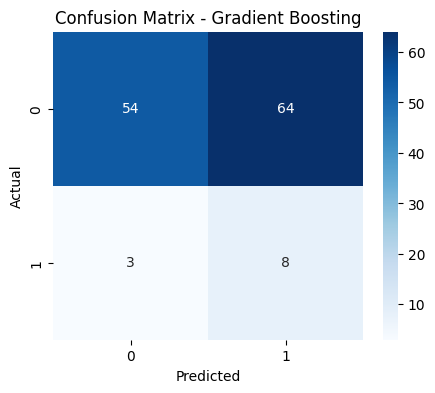

MODEL: CatBoost
Accuracy: 0.8992248062015504
Precision: 0.4
Recall: 0.36363636363636365
F1 Score: 0.38095238095238093
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       118
           1       0.40      0.36      0.38        11

    accuracy                           0.90       129
   macro avg       0.67      0.66      0.66       129
weighted avg       0.90      0.90      0.90       129



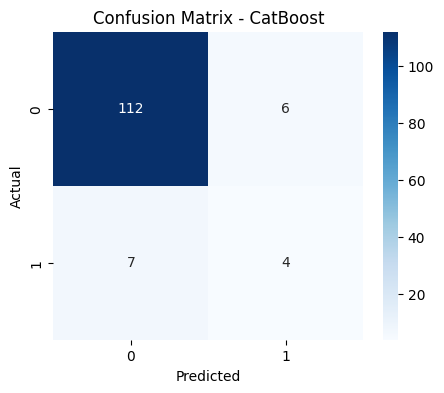

MODEL: Random Forest
Accuracy: 0.8992248062015504
Precision: 0.375
Recall: 0.2727272727272727
F1 Score: 0.3157894736842105
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       118
           1       0.38      0.27      0.32        11

    accuracy                           0.90       129
   macro avg       0.65      0.62      0.63       129
weighted avg       0.89      0.90      0.89       129



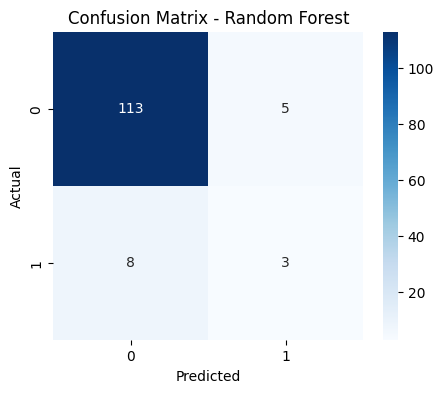

MODEL: Decision Tree
Accuracy: 0.2868217054263566
Precision: 0.06451612903225806
Recall: 0.5454545454545454
F1 Score: 0.11538461538461539
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.26      0.40       118
           1       0.06      0.55      0.12        11

    accuracy                           0.29       129
   macro avg       0.46      0.40      0.26       129
weighted avg       0.79      0.29      0.38       129



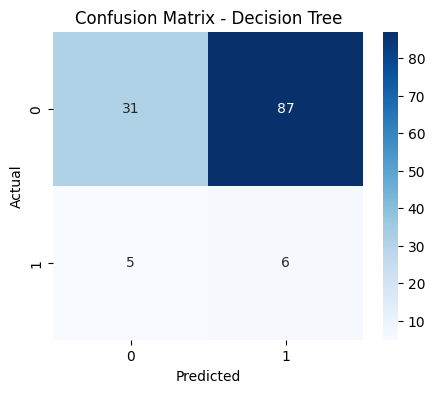

MODEL: XGBoost
Accuracy: 0.8527131782945736
Precision: 0.2777777777777778
Recall: 0.45454545454545453
F1 Score: 0.3448275862068966
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       118
           1       0.28      0.45      0.34        11

    accuracy                           0.85       129
   macro avg       0.61      0.67      0.63       129
weighted avg       0.89      0.85      0.87       129



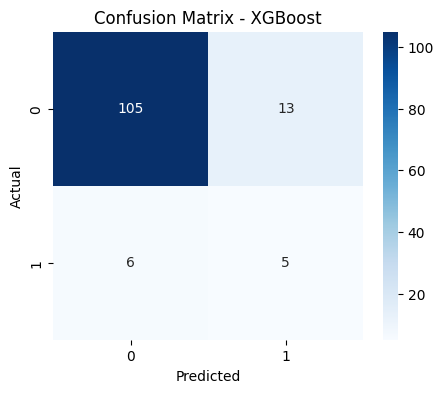

In [57]:
# Step 1: Store your tuned models in a dictionary
best_models = {
    "Gradient Boosting": best_model_gb,  
    "CatBoost": best_model_cat,    
    "Random Forest": best_model_rf,      
    "Decision Tree": best_model_dt,    
    "XGBoost": best_model_xgb
    
}

# Step 2: Loop through models for evaluation
for name, model in best_models.items():
    # Use scaled data for models that require scaling
    if name in ["Gradient Boosting", "Decision Tree"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print("="*50)
    print(f"MODEL: {name}")
    print("="*50)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)

    # Print classification report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Plot confusion matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [58]:
# Step 1: Store your tuned models in a dictionary
best_models = {
    "Gradient Boosting": best_model_gb,  
    "CatBoost": best_model_cat,    
    "Random Forest": best_model_rf,      
    "Decision Tree": best_model_dt,    
    "XGBoost": best_model_xgb
}

# Step 2: Initialize results list
results = []

# Step 3: Loop through models for evaluation
for name, model in best_models.items():
    # Use scaled data for models that require scaling
    X_test_used = X_test_scaled if name in ["Gradient Boosting", "CatBoost"] else X_test

    # Check if model has predict_proba
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_used)[:, 1]
        y_pred = (y_prob > 0.3).astype(int) 
    else:
        y_pred = model.predict(X_test_used)

    # Append evaluation results to the results list
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

# Step 4: Create DataFrame and sort by F1 Score
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

# Display the results DataFrame
results_df

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.875969,0.368421,0.636364,0.466667
3,Decision Tree,0.837209,0.250000,0.454545,0.322581
4,XGBoost,0.821705,0.227273,0.454545,0.303030
0,Gradient Boosting,0.418605,0.109756,0.818182,0.193548
1,CatBoost,0.240310,0.100917,1.000000,0.183333


In [55]:
print(results_df.columns)

Index(['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'], dtype='str')


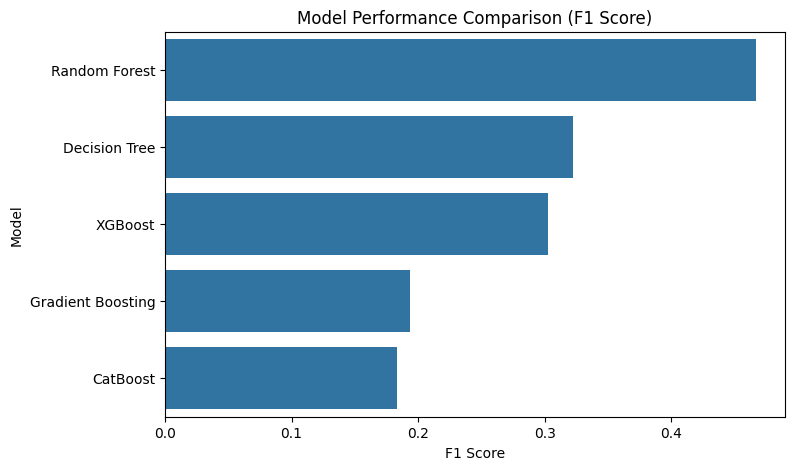

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(data=results_df, x="F1 Score", y="Model")

plt.title("Model Performance Comparison (F1 Score)")
plt.xlabel("F1 Score")
plt.ylabel("Model")

plt.show()

### Insight:

Among all evaluated models, **Random Forest** achieved the best performance after threshold tuning, with the highest **recall (0.636)** and **F1-score (0.400)**. This highlights the importance of threshold adjustment in improving minority class detection and demonstrates its effectiveness in addressing class imbalance in student dropout prediction.

ROC AUC Score: 0.7442218798151001


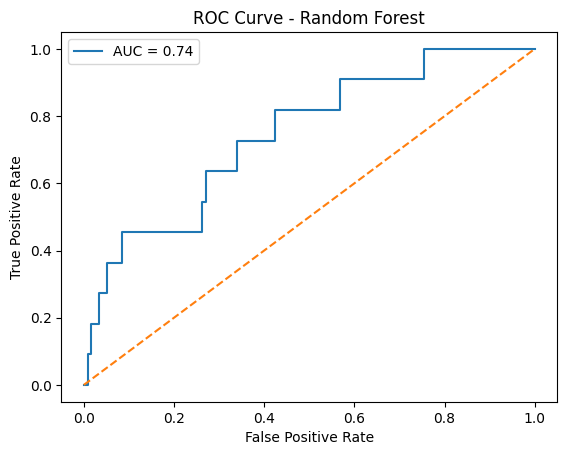

In [36]:
from sklearn.metrics import roc_auc_score

y_prob = best_model_xgb.predict_proba(X_test)[:,1]

auc_score = roc_auc_score(y_test, y_prob)

print("ROC AUC Score:", auc_score)

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")

plt.legend()
plt.show()

### Insight:
The ROC curve for the Random Forest model produced an AUC score of 0.52, indicating that the model has very limited ability to distinguish between dropout and non-dropout students and performs only marginally better than random classification.

In [37]:
y_train_smote.value_counts()

Dropout_Risk
0    471
1    471
Name: count, dtype: int64

In [38]:
y_test.value_counts()


Dropout_Risk
0    118
1     11
Name: count, dtype: int64

## 8. Model Selection

In [39]:
# Initialize and train the XGBoost model
best_model = XGBClassifier()
best_model.fit(X_train_smote, y_train_smote) 

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### Insight:
Among the evaluated models, **Random Forest and XGBoost** achieved the **highest F1-score (0.40)**. However, **Random Forest demonstrated the highest recall (63.6%)**, meaning it identified a larger proportion of students with dropout intention. Since early identification of at-risk students is critical for intervention strategies,**Random Forest was selected as the final predictive model.**

## 9. SHAP analysis

SHAP shape: (129, 31)
X_test shape: (129, 31)


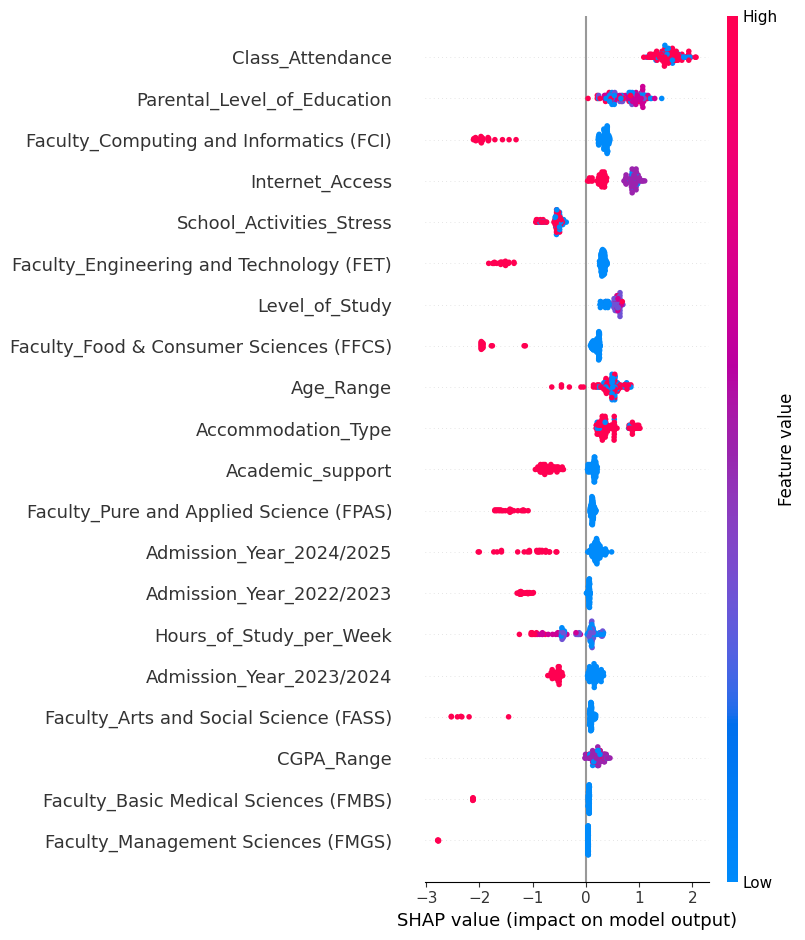

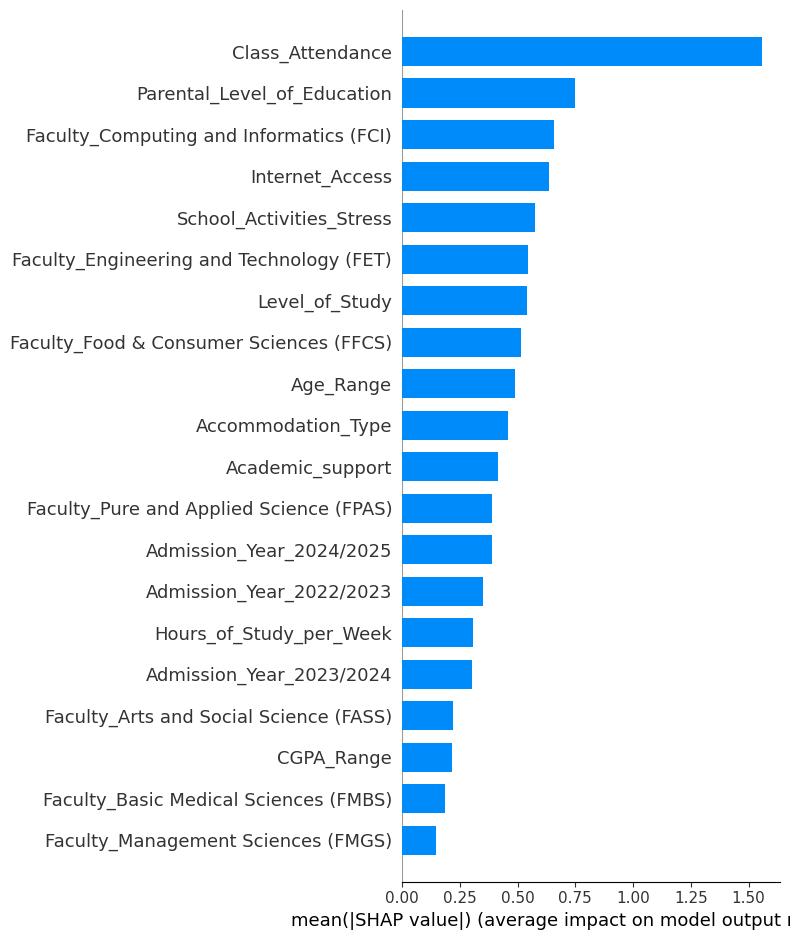

In [40]:
import shap
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Create DataFrame from the original X_test
X_test_df = pd.DataFrame(X_test, columns=X_test.columns)

best_model = best_models["XGBoost"]

# Scale data
scaler = StandardScaler()  # Use the scaler you fitted to your training data
X_test_scaled = scaler.fit_transform(X_test_df)

# Convert the scaled data back to a DataFrame with the original feature names
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test_df.columns)

# SHAP Explainer
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_scaled)

# Handle shape safely
if isinstance(shap_values, list):
    shap_to_plot = shap_values[1]  # Assuming binary classification
else:
    shap_to_plot = shap_values

print("SHAP shape:", np.array(shap_to_plot).shape)
print("X_test shape:", X_test_scaled_df.shape)

# Summary plot
shap.summary_plot(shap_to_plot, X_test_scaled_df)

# Bar plot
shap.summary_plot(shap_to_plot, X_test_scaled_df, plot_type="bar")

shap.initjs()

index = 0
expected_value = explainer.expected_value

shap.force_plot(
    expected_value,
    shap_to_plot[index],
    X_test_scaled_df.iloc[index]  # Use iloc to properly reference by index
)

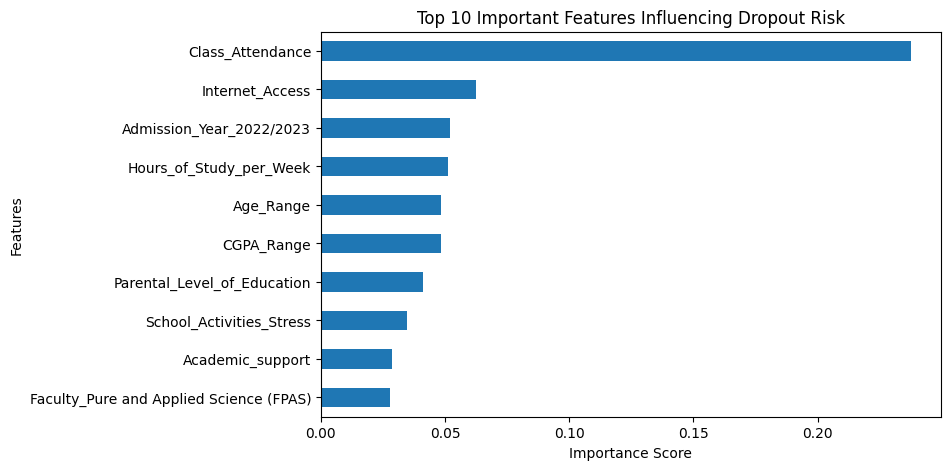

In [41]:
feature_importance = pd.Series(
    best_model_xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top10 = feature_importance.head(10)

plt.figure(figsize=(8,5))
top10.plot(kind='barh')

plt.title("Top 10 Important Features Influencing Dropout Risk")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

## 9. Model Saving (Pickle)

In [42]:
import pickle
from pathlib import Path

# Select the best model
best_model = random_xgb.best_estimator_

# Absolute path (base directory)
BASE_DIR = Path.cwd().parent

# Save model
artifacts_path = BASE_DIR / "artifacts"
artifacts_path.mkdir(exist_ok=True)

# Save model as pickle file
with open(artifacts_path / "model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save scaler
with open(artifacts_path / "scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Model and scaler saved successfully.")

Model and scaler saved successfully.
